In [2]:
import pandas as pd

In [3]:
df=pd.read_csv('data/cancer_data.csv')
df.head()

,age,gender,bmi,smoking,genetic_risk,physical_activity,alcohol_intake,cancer_history,diagnosis
0,58,1,16.085313,0,1,8.146251,4.148219,1,1
1,71,0,30.828784,0,1,9.361630,3.519683,0,0
2,48,1,38.785084,0,2,5.135179,4.728368,0,1
3,34,0,30.040295,0,0,9.502792,2.044636,0,0
4,62,1,35.479721,0,0,5.356890,3.309849,0,1


In [4]:
df.columns

Index(['age', 'gender', 'bmi', 'smoking', 'genetic_risk', 'physical_activity',
       'alcohol_intake', 'cancer_history', 'diagnosis'],
      dtype='str')

In [5]:
df.isnull().sum()

age                  0
gender               0
bmi                  0
smoking              0
genetic_risk         0
physical_activity    0
alcohol_intake       0
cancer_history       0
diagnosis            0
dtype: int64

In [6]:
from sklearn.model_selection import train_test_split

x=df.drop('diagnosis',axis=1)
y=df.diagnosis

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.25,random_state=42)

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,confusion_matrix

model=RandomForestClassifier()
model.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [8]:
y_pred=model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.91      0.96      0.94       233
           1       0.93      0.85      0.89       142

    accuracy                           0.92       375
   macro avg       0.92      0.91      0.91       375
weighted avg       0.92      0.92      0.92       375



# Ada boosting algorithm

In [9]:
from sklearn.ensemble import AdaBoostClassifier

model = AdaBoostClassifier(
    n_estimators=10,#number of weak learners
    learning_rate=0.1,#contribution of each learner
    random_state=42
)

model.fit(x_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",10
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",0.1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


## model evaluation

In [10]:
y_pred=model.predict(x_test)

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.71      0.96      0.81       233
           1       0.84      0.35      0.49       142

    accuracy                           0.73       375
   macro avg       0.78      0.65      0.65       375
weighted avg       0.76      0.73      0.69       375



<Axes: >

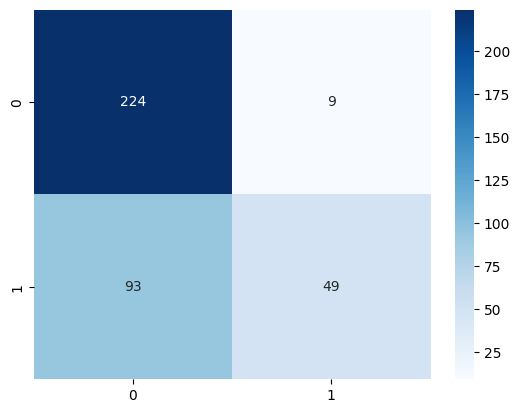

In [11]:
import seaborn as sns
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')

# Gradient Boosting

## Gradient Boosting (regression)

In [12]:
df=pd.read_csv('data/ad_spend.csv')
df.sample(5)

,Ad Spend ($),Season,Revenue ($)
120,937,Winter,1317
87,325,Winter,392
185,941,Winter,1607
64,942,Summer,1045
164,470,Summer,597


In [13]:
df.shape

(200, 3)

### understanding data frame

In [14]:
g=df.groupby('Season')[['Revenue ($)','Ad Spend ($)']].mean().round(2)
g

,Revenue ($),Ad Spend ($)
Season,,
Monsoon,423.15,517.64
Summer,689.36,573.84
Winter,826.53,552.56


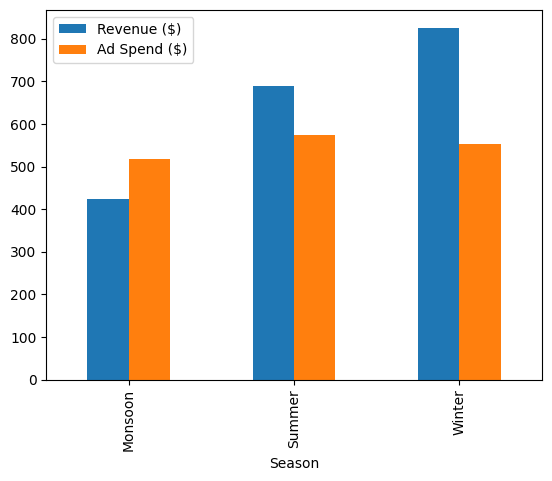

In [15]:
import matplotlib.pylab as plt
g.plot(kind="bar")
plt.show()

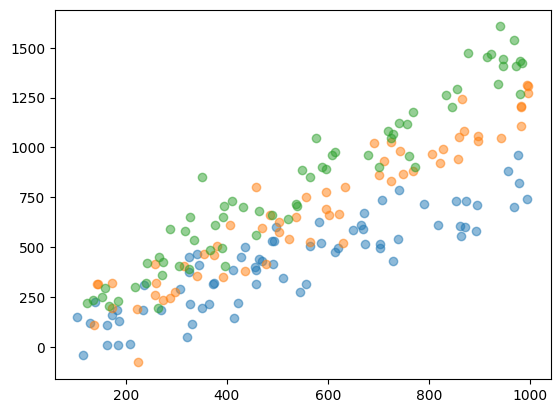

In [16]:
for season,subdf in df.groupby("Season"):
    plt.scatter(subdf['Ad Spend ($)'],subdf['Revenue ($)'],alpha=0.5)

In [17]:
df_encoded=pd.get_dummies(df,columns=['Season'],drop_first=True)

In [18]:
df_encoded.head()

,Ad Spend ($),Revenue ($),Season_Summer,Season_Winter
0,463,440,False,False
1,158,297,False,True
2,328,214,False,False
3,322,48,False,False
4,726,1048,False,True


In [19]:
from sklearn.model_selection import train_test_split
x=df_encoded.drop('Revenue ($)',axis=1)
y=df_encoded['Revenue ($)']

In [20]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.25,random_state=42)

### model training

In [21]:
from sklearn.ensemble import GradientBoostingRegressor

model=GradientBoostingRegressor(
    n_estimators=65,      # Number of trees
    learning_rate=0.1,    # Contribution of each tree
    max_depth=3,          # Maximum depth of each tree
    min_samples_split=2,  # Minimum samples required to split
    min_samples_leaf=1,   # Minimum samples in a leaf
    subsample=1.0,        # Fraction of training data used
    loss='squared_error', # Loss function
    random_state=42       # Reproducible results
)
model.fit(x_train,y_train)
model.score(x_test,y_test)

0.8879287534915072

In [22]:
y_pred=model.predict(x_test)

df_ev=pd.DataFrame({'actual':y_test,'predicted':y_pred})
df_ev.head()

,actual,predicted
95,903,952.057423
15,1047,896.081264
30,1026,886.242668
158,1203,1281.524816
128,558,667.574717


In [23]:
df_ev['diff (%)']=abs((df_ev['predicted']-df_ev['actual'])*100/df_ev['actual'])
df_ev.head()

,actual,predicted,diff (%)
95,903,952.057423,5.432716
15,1047,896.081264,14.414397
30,1026,886.242668,13.621572
158,1203,1281.524816,6.527416
128,558,667.574717,19.637046


## Gradient boosting (Classifier)

In [24]:
df=pd.read_csv('data/titanic.csv')
df.sample(5)

,passenger_id,name,p_class,sex,age,sib_sp,parch,ticket,fare,cabin,embarked,survived
166,167,"Chibnall, Mrs. (Edith Martha Bowerman)",1,female,NaN,0,1,113505,55.00,E33,S,1
302,303,"Johnson, Mr. William Cahoone Jr",3,male,19.0,0,0,LINE,0.00,NaN,S,0
89,90,"Celotti, Mr. Francesco",3,male,24.0,0,0,343275,8.05,NaN,S,0
489,490,"Coutts, Master. Eden Leslie ""Neville""",3,male,9.0,1,1,C.A. 37671,15.90,NaN,S,1
818,819,"Holm, Mr. John Fredrik Alexander",3,male,43.0,0,0,C 7075,6.45,NaN,S,0


In [25]:
df.isnull().sum()

passenger_id      0
name              0
p_class           0
sex               0
age             177
sib_sp            0
parch             0
ticket            0
fare              9
cabin           687
embarked          2
survived          0
dtype: int64

<Axes: xlabel='age', ylabel='Count'>

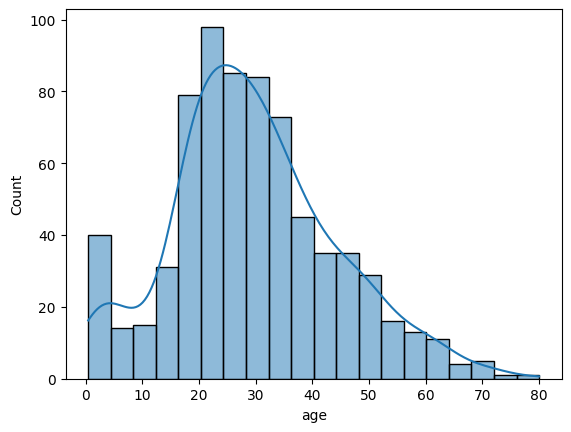

In [26]:
import seaborn as sns

sns.histplot(df.age,kde=True)

In [27]:
# using median because it is right skewed(positive skewed)
df['age']=df['age'].fillna(df['age'].median())

In [28]:
df.columns

Index(['passenger_id', 'name', 'p_class', 'sex', 'age', 'sib_sp', 'parch',
       'ticket', 'fare', 'cabin', 'embarked', 'survived'],
      dtype='str')

In [29]:
df.shape

(891, 12)

In [30]:
df.survived.value_counts()

survived
0    549
1    342
Name: count, dtype: int64

In [31]:
df.drop('name',axis=1,inplace=True)
df.drop('cabin',axis=1,inplace=True)

In [32]:
df['sex']=df['sex'].map({'male':1,'female':0})

In [33]:
df.head()

,passenger_id,p_class,sex,age,sib_sp,parch,ticket,fare,embarked,survived
0,1,3,1,22.0,1,0,A/5 21171,7.2500,S,0
1,2,1,0,38.0,1,0,PC 17599,71.2833,C,1
2,3,3,0,26.0,0,0,STON/O2. 3101282,NaN,S,1
3,4,1,0,35.0,1,0,113803,53.1000,S,1
4,5,3,1,35.0,0,0,373450,8.0500,S,0


In [34]:
df.columns

Index(['passenger_id', 'p_class', 'sex', 'age', 'sib_sp', 'parch', 'ticket',
       'fare', 'embarked', 'survived'],
      dtype='str')

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix

x=df[['p_class','sex','age','sib_sp','parch']]
y=df['survived']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

In [36]:
from sklearn.ensemble import GradientBoostingClassifier
model_gbc=GradientBoostingClassifier(n_estimators=55)

model_gbc.fit(x_train,y_train)

y_pred=model_gbc.predict(x_test)

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.81      0.90      0.85       134
           1       0.81      0.69      0.74        89

    accuracy                           0.81       223
   macro avg       0.81      0.79      0.80       223
weighted avg       0.81      0.81      0.81       223



<Axes: >

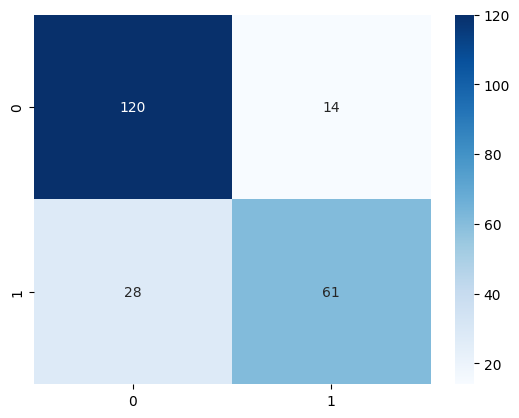

In [37]:
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')

# XGboosting

## XGboosting (regression)

In [38]:
from xgboost import XGBRegressor
import pandas as pd

### sklearns data set

In [39]:
from sklearn.datasets import fetch_california_housing
housing=fetch_california_housing()

In [40]:
print(dir(housing))
print(housing.feature_names)
print(housing.target)

['DESCR', 'data', 'feature_names', 'frame', 'target', 'target_names']
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
[4.526 3.585 3.521 ... 0.923 0.847 0.894]


In [41]:
print(housing.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [42]:
df=pd.DataFrame(housing.data,columns=housing.feature_names)
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [43]:
df.shape

(20640, 8)

In [44]:
df['Medhouseval']=housing.target
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Medhouseval
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [45]:
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
Medhouseval    0
dtype: int64

In [46]:
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'Medhouseval'],
      dtype='str')

In [47]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Medhouseval
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [48]:
x=df.drop('Medhouseval',axis='columns')
y=df['Medhouseval']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.25,random_state=42)

In [49]:
import time

xgb_model=XGBRegressor(   
    n_estimators=100,       # Number of decision trees
    learning_rate=0.1,     # Contribution of each tree
    max_depth=3,            # Maximum depth of each tree
    subsample=1.0,          # Percentage of rows used for each tree
    colsample_bytree=1.0,   # Percentage of features used for each tree
    reg_alpha=0,            # L1 regularization
    reg_lambda=1,           # L2 regularization
    random_state=42         # Makes results reproducible
)
start=time.time()
xgb_model.fit(x_train,y_train)
end=time.time()

In [50]:
print('time:',end-start)

time: 0.2266528606414795


In [51]:
xgb_model.score(x_test,y_test)

0.7820564672358439

XGBoost (Extreme Gradient Boosting) predicts by adding up many small decision trees. Each new tree is trained to fix the errors the earlier trees left behind. These notes cover regression, where the target is a number such as a price or a quantity.

Key points:
1. Start with one guess. Every sample gets the same first prediction, 0.5 by default, whatever the data.
2. Compute residuals. Residual = observed value − predicted value. Each new tree is fit to these residuals, not to the raw target.
3. Use XGBoost's own tree type. Every tree starts as a single leaf holding all the residuals.
4. Similarity score per node. It measures how alike the residuals in a node are:
    ◦ Similarity = (sum of residuals)² ÷ (number of residuals + λ)
    ◦ Residuals with opposite signs cancel out, so mixed nodes score low.
    ◦ λ (lambda) is a regularization setting that shrinks the score.
5. Pick splits by Gain. Gain = left similarity + right similarity − parent similarity. Try each threshold (midpoints between sorted values); keep the one with the largest Gain.
6. Keep splitting. Repeat inside each branch. Depth is capped at 6 levels by default.
7. Prune with gamma (γ). Working from the bottom up, drop a branch when Gain − γ is negative. A parent stays if any child below it survives.
8. Effect of lambda. A higher λ lowers similarity and Gain, so pruning happens more often. It also reduces how sensitive the model is to single samples.
9. Output value per leaf. Output = sum of residuals ÷ (number of residuals + λ). With λ = 0, this is just the average residual.
10. Update predictions. New prediction = previous prediction + learning rate (eta, default 0.3) × tree output.
11. Repeat. Compute new residuals and build the next tree. Stop when residuals are very small or when the tree limit is reached.

## XGB (classifier)

In [52]:
from sklearn.datasets import make_classification
x,y=make_classification(
    n_samples=10000,
    n_features=10,
    n_informative=8,
    n_redundant=2,
    n_repeated=0,
    n_classes=3,
    random_state=42
)

Key Characteristics of XGBoost
1. Ensemble Learning
XGBoost combines multiple decision trees to make one strong model.

Tree 1 + Tree 2 + Tree 3 + ... → Final Model
2. Boosting Algorithm

Trees are built sequentially. Each new tree tries to improve the errors of the existing model.

3. Gradient + Hessian
Unlike a simple gradient-based explanation, XGBoost uses:

First-order gradient
Second-order gradient (Hessian)

to optimize the objective.

4. Regularization
XGBoost includes regularization to control overfitting.

reg_alpha → L1 regularization
reg_lambda → L2 regularization
gamma → controls whether a split provides enough improvement
5. High Performance
XGBoost is designed to be computationally efficient and can use multiple CPU cores.

6. Learning Rate
learning_rate controls how much each new tree contributes.

7. Tree Complexity Control
max_depth controls how deep each tree can grow.

8. Row and Feature Sampling
XGBoost can use subsets of data and features.

subsample → rows
colsample_bytree → features

This can improve generalization and reduce overfitting.

9. Handles Missing Values
XGBoost has built-in mechanisms for handling missing feature values during tree construction, so you don't always need to manually impute every missing value.

10. Works for Both Regression and Classification
XGBRegressor  → Continuous values
XGBClassifier → Classes / probabilities
11. Feature Importance
XGBoost can provide feature-importance measures to help understand which features contributed to the model.
model.feature_importances_
12. Doesn't Usually Require Feature Scaling
Because XGBoost is tree-based, you generally don't need StandardScaler or MinMaxScaler just because you're using XGBoost.

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.25,random_state=42)

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.25,random_state=42)

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.25,random_state=42)

In [54]:
from xgboost import XGBClassifier

xgbc_model=XGBClassifier(
    n_estimators=100,       # Number of decision trees
    learning_rate=0.1,      # Contribution of each tree
    max_depth=3,            # Maximum depth of each tree
    subsample=1.0,          # Percentage of rows used for each tree
    colsample_bytree=1.0,   # Percentage of features used for each tree
    reg_alpha=0,            # L1 regularization
    reg_lambda=1,           # L2 regularization
    random_state=42
)

xgbc_model.fit(x_train,y_train)

y_pred=xgbc_model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.79      0.82      0.80       853
           1       0.85      0.84      0.84       807
           2       0.82      0.80      0.81       840

    accuracy                           0.82      2500
   macro avg       0.82      0.82      0.82      2500
weighted avg       0.82      0.82      0.82      2500

